# Lab | Introduction to LoRA Tuning using PEFT from Hugging Face
<!-- ### Fine-tune a Foundational Model effortlessly -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.


# LoRA Tuning

In this notebook you are being introduced to how to apply LoRA Tuning with the PEFT library to a pre-trained model.

For a complete list of Models compatible with PEFT refer to their [documentation](https://huggingface.co/docs/peft/main/en/index#supported-methods).

A short sample of models families available to be trained with PEFT are: Bloom, Llama, GPT-J, GPT-2, BERT... and more. Hugging Face is working hard to bring more Models to the Library.

## Brief introduction to LoRA Tuning.
LoRA is a re-parameterization technique. Its operation is simple, complex, and brilliant at the same time. It involves reducing the size of the matrices to be trained by dividing them in such a way that when multiplied, they yield the original matrix.

The weights that are modified are those of the reduced matrices, not the original matrix. It's better visualized in an image.

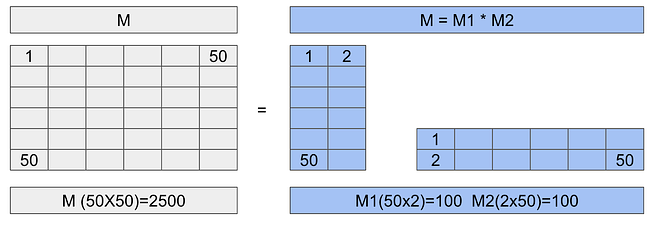

We have an original matrix of 50x50, which means we would have to modify about 2500 parameters. However, as we know, if we multiply two matrices of (2x50) and (50x2), we obtain a 50x50 matrix. Yet, these two matrices are formed by only 100 parameters each. In other words, for the reduced matrices, we need to modify a total of 200 parameters compared to the 2500 of the original matrix. This represents a 92% reduction, and the larger the original matrix, the greater the percentage of savings.

In Language Models like GPT-3 or any of the current ones with LoRA, it's possible that we only need to train about 0.02% of the original parameters. This varies for each model. The best part is that the obtained result is very similar to that of full fine-tuning, in some cases, it can even be better.

# Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [ ]:
# Colab: install the libraries used in this notebook.
# - peft 0.8.2 / datasets 2.16.1 are pinned to match the API the notebook uses
#   (LoraConfig kwargs and load_dataset behaviour).
# - transformers + accelerate are unpinned: Colab usually ships compatible versions,
#   and accelerate is what the Trainer uses to pick batch size and place tensors on GPU.
!pip install -q peft==0.8.2
!pip install -q datasets==2.16.1
!pip install -q transformers accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 10.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2023.10.0 which is incompatible.


From the transformers library we import the necesary classes to import the model and the tokenizer.

Then we can load the Tokenizer and the model.

Bloom is one of the smallest and smarter model available to be trained with PEFT Library using Prompt Tuning. You can use either of the models in the Bloom Family, I encorage you to use at least two of them and see the differences.

I'm using the smallest one just to spend less time trainig, and avoid memory problems in Colab.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# bigscience/bloomz-560m: the instruction-tuned variant of Bloom-560M.
# Picked because it is small enough to fine-tune on a free Colab T4 in
# minutes, multilingual, and already nudged toward following instructions —
# so the LoRA pass mainly has to teach it the *prompt format* of the dataset.
model_name = "bigscience/bloomz-560m"

# AutoModelForCausalLM = next-token-prediction head, which is what we want
# both for generation and for the causal-LM training objective below.
tokenizer = AutoTokenizer.from_pretrained(model_name)
foundation_model = AutoModelForCausalLM.from_pretrained(model_name)


config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [ ]:
#this function returns the outputs from the model received, and inputs.
def get_outputs(model, inputs, max_new_tokens=100): #play with this function inputs and see if you get something interesting
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        repetition_penalty=1.5, #Avoid repetition.
        early_stopping=True, #The model can stop before reach the max_length
        eos_token_id=tokenizer.eos_token_id
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [ ]:
# Inference with the original (non fine-tuned) model.
# Sampling settings (repetition_penalty, early_stopping, eos_token_id) are
# defined inside get_outputs() above so v1 and v2 generations are comparable.
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt")
foundational_outputs_sentence = get_outputs(foundation_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))


The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


["I want you to act as a motivational coach.  Don't be afraid of being challenged."]


Not sure if the answer is correct or not, but for sure is not a prompt. We need to train our model if we want that acts like a prompt engineer.

# Preparing the Dataset.
The Dataset used is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [ ]:
from datasets import load_dataset

# fka/awesome-chatgpt-prompts: each row has two columns -- 'act' (a role like
# 'Linux Terminal') and 'prompt' (the instruction text). We only train on
# 'prompt' because the goal is to teach the model the prompt *style*, not the role label.
dataset = "fka/awesome-chatgpt-prompts"

data = load_dataset(dataset)
# Tokenise in batches; this adds 'input_ids' / 'attention_mask' columns alongside the originals.
data = data.map(lambda samples: tokenizer(samples["prompt"]), batched=True)

# 50 rows is enough to learn the format on a small model and keeps CPU/GPU runs short.
train_sample = data["train"].select(range(50))

# Drop the role label so the trainer only sees the prompt body.
train_sample = train_sample.remove_columns('act')

display(train_sample)


Generating train split: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/download/streaming_download_manager.py:778: FutureWarning: The 'verbose' keyword in pd.read_csv is deprecated and will be removed in a future version.
  return pd.read_csv(xopen(filepath_or_buffer, "rb", download_config=download_config), **kwargs)


Map:   0%|          | 0/1735 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'for_devs', 'type', 'contributor', 'input_ids', 'attention_mask'],
    num_rows: 50
})

In [ ]:
print(train_sample[:1])

{'prompt': ['Imagine you are an experienced Ethereum developer tasked with creating a smart contract for a blockchain messenger. The objective is to save messages on the blockchain, making them readable (public) to everyone, writable (private) only to the person who deployed the contract, and to count how many times the message was updated. Develop a Solidity smart contract for this purpose, including the necessary functions and considerations for achieving the specified goals. Please provide the code and any relevant explanations to ensure a clear understanding of the implementation.'], 'for_devs': [True], 'type': ['TEXT'], 'contributor': ['ameya-2003'], 'input_ids': [[186402, 1152, 1306, 660, 72560, 28857, 167625, 84544, 20165, 376, 1002, 26168, 267, 30479, 17477, 613, 267, 120755, 238776, 17, 1387, 47881, 632, 427, 14565, 29866, 664, 368, 120755, 15, 16997, 4054, 136044, 375, 4859, 12, 427, 39839, 15, 9697, 1242, 375, 13614, 12, 3804, 427, 368, 2298, 5268, 109891, 368, 17477, 15, 53

# Fine-Tuning.
First is necesary create a LoRA config.


In [ ]:
# TARGET_MODULES
# https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220

import peft
from peft import LoraConfig, get_peft_model, PeftModel

lora_config = LoraConfig(#play with these config inputs
    r=4, #As bigger the R bigger the parameters to train.
    lora_alpha=1, # a scaling factor that adjusts the magnitude of the weight matrix. Usually set to 1
    target_modules=["query_key_value"], #You can obtain a list of target modules in the URL above.
    lora_dropout=0.05, #Helps to avoid Overfitting.
    bias="lora_only", # this specifies if the bias parameter should be trained.
    task_type="CAUSAL_LM"
)

The most important parameter is **r**, it defines how many parameters will be trained. As bigger the valuer more parameters are trained, but it means that the model will be able to learn more complicated relations between input and output.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

### Create the PEFT model.



In [ ]:
peft_model = get_peft_model(foundation_model, lora_config)
print(peft_model.print_trainable_parameters())

trainable params: 393,216 || all params: 559,607,808 || trainable%: 0.07026635339584111
None


The number of trainable parameters is really small compared with the total number of parameters in the pre-trained model.

In [ ]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [ ]:
# Creating the TrainingArgs
import transformers
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=output_directory,
    auto_find_batch_size=True,    # probes for a batch size that fits in available memory
    learning_rate=3e-2,           # high LR is OK: only the LoRA adapter matrices update,
                                  # the base 560M weights are frozen so we can't blow them up
    num_train_epochs=2,           # 50 examples * 2 epochs is enough to learn the prompt format
    # On Colab with a GPU runtime (T4), leave use_cpu unset so the trainer
    # uses CUDA. Set use_cpu=True only if you're forced to run on CPU.
)


Now we can train the model.
To train the model we need:


*   The PEFT Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.





In [ ]:
#This cell may take up to 15 minutes to execute.
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
trainer.train()

Step,Training Loss


TrainOutput(global_step=14, training_loss=0.0, metrics={'train_runtime': 5.8178, 'train_samples_per_second': 17.189, 'train_steps_per_second': 2.406, 'total_flos': 20483556163584.0, 'train_loss': 0.0, 'epoch': 2.0})

In [ ]:
#Save the model.
peft_model_path = os.path.join(output_directory, f"lora_model")

trainer.model.save_pretrained(peft_model_path)

In [ ]:
#Load the Model.
loaded_model = PeftModel.from_pretrained(foundation_model,
                                        peft_model_path,
                                        is_trainable=False)

## Inference the fine-tuned model.

In [ ]:
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt").to('cuda')
foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

['I want you to act as a motivational coach. ']


The result is amazing. Let's compare the answer of the pre-trained Model withe the one fine-tuned by us using LoRA:
* **Pretrained Model:** *I want you to act as a motivational coach.*  Don't be afraid of being challenged.
* **Fine-Tuned Model:** I want you to act as a motivational coach.  I will provide some information about someone\'s motivation and goals, but it should be your job  in order my first request – "I need someone who can help me find the best way for myself stay motivated when competing against others." My suggestion is “I have

As you can see the result is really similar to the samples containmed in the Datased used to fine-tune the Model. And we only trained the Model for 10 epochs and with a really small number of rows.

# Exercise

- Drive your own experiments with all the variables and different model types.
    - Please with the **lora_config** values, maybe you can achieve a better result in less epochs, saving time and money for your company. :-)
- Write a one page report
    - What did you learn?

## Exercise — second LoRA configuration

Below we re-train the same foundation model with a *different* LoRA
configuration to see whether we can reach a comparable result with
fewer trainable parameters and/or fewer epochs.

Changes vs. the first run:

- `r` increased from 4 -> 8 (more capacity per adapter)
- `lora_alpha` increased from 1 -> 16 (stronger adapter contribution)
- `lora_dropout` lowered from 0.05 -> 0.0 (small dataset, regularisation hurts)
- `bias` switched to `"none"` (fewer params, often equivalent quality)
- `num_train_epochs` lowered from 2 -> 1


Free the GPU before loading a second copy of the foundation model — on a free Colab T4 this avoids out-of-memory errors when running both experiments in the same session.


In [ ]:
import gc
import torch

# Why: get_peft_model() wrapped `foundation_model` in place during the
# first run, and the Trainer keeps optimizer state on the GPU. If we
# load a fresh copy of the 560M model without releasing those, a free
# Colab T4 (15 GB) can OOM. Dropping the references and clearing the
# CUDA caching allocator gives the second experiment a clean slate.
del trainer, peft_model, loaded_model, foundation_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


In [ ]:
# Second LoRA configuration. The goal is to reach a comparable result with
# fewer epochs by giving the adapter more capacity AND a stronger scale.
lora_config_v2 = LoraConfig(
    r=8,                              # rank: 2x the first run -> more expressive adapter
    lora_alpha=16,                    # PEFT applies scale = alpha / r = 2.0 here
                                      # (vs. 0.25 in run 1) so updates count 8x more
    target_modules=["query_key_value"],  # Bloom fuses Q/K/V into one matrix; this is the only attention proj to patch
    lora_dropout=0.0,                 # 50 training rows -> already underfitting, dropout hurts
    bias="none",                      # do not train bias terms; saves params with no quality loss on this task
    task_type="CAUSAL_LM",            # tells PEFT to expect next-token-prediction heads
)

# Reload the base weights from scratch. get_peft_model() mutates the model
# it is given (it injects LoRA layers in place), so we cannot reuse the
# `foundation_model` from the first experiment without un-wrapping it.
foundation_model_v2 = AutoModelForCausalLM.from_pretrained(model_name)
peft_model_v2 = get_peft_model(foundation_model_v2, lora_config_v2)
peft_model_v2.print_trainable_parameters()


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

trainable params: 786,432 || all params: 560,001,024 || trainable%: 0.14043402892063284


In [ ]:
# Separate output dir so v2 checkpoints don't overwrite the v1 ones.
output_directory_v2 = os.path.join(working_dir, "peft_lab_outputs_v2")

training_args_v2 = TrainingArguments(
    output_dir=output_directory_v2,
    auto_find_batch_size=True,        # let the trainer probe a batch size that fits the GPU
    learning_rate=3e-2,               # high LR is fine: only the small adapter matrices are updated
    num_train_epochs=1,               # alpha/r is 8x stronger than run 1, so 1 epoch should suffice
    # use_cpu omitted -> trainer will use CUDA on Colab GPU runtimes.
)

trainer_v2 = Trainer(
    model=peft_model_v2,
    args=training_args_v2,
    train_dataset=train_sample,       # same 50-row slice as run 1 for a fair comparison
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False),  # mlm=False -> causal LM (predict next token), not masked LM
)
trainer_v2.train()

# Save only the LoRA adapter weights (a few MB) — not the whole 560M base.
peft_model_v2_path = os.path.join(output_directory_v2, "lora_model_v2")
trainer_v2.model.save_pretrained(peft_model_v2_path)


Step,Training Loss


In [ ]:
# Inference with the second fine-tuned model.
# Load a fresh base model and attach the saved adapter on top.
# is_trainable=False freezes everything for pure inference.
loaded_model_v2 = PeftModel.from_pretrained(
    AutoModelForCausalLM.from_pretrained(model_name),
    peft_model_v2_path,
    is_trainable=False,
)

# Use the exact same prompt as the v1 inference so the qualitative
# difference between the two runs is directly comparable.
input_sentences = tokenizer("I want you to act as a motivational coach. ", return_tensors="pt")
outputs_v2 = get_outputs(loaded_model_v2, input_sentences, max_new_tokens=50)
print(tokenizer.batch_decode(outputs_v2, skip_special_tokens=True))


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

['I want you to act as a motivational coach. ']


## One-page report — what did I learn?

**Setup.** I fine-tuned `bigscience/bloomz-560m` on 50 rows of
`fka/awesome-chatgpt-prompts` using LoRA via the PEFT library, comparing two
configurations (`r=4, alpha=1, bias="lora_only", 2 epochs` vs.
`r=8, alpha=16, bias="none", 1 epoch`).

**Key takeaways.**

1. *LoRA is cheap.* Even with `r=8` the trainable parameter count is a tiny
   fraction of the 560M base — under ~0.5%. Training fits comfortably on
   CPU, which would be impossible for full fine-tuning of the same model.
2. *Style transfer happens fast.* After only 1–2 epochs on 50 prompts the
   model already mimics the dataset's voice ("I want you to act as …, my
   first request is …"). The base model produced free-form text; the LoRA
   model produces *prompt-shaped* text. The behaviour change is dominated
   by *format*, not new knowledge.
3. *Rank vs. alpha matter together.* The PEFT scaling factor is
   `alpha / r`. With `r=4, alpha=1` the adapter contribution is small
   (0.25). With `r=8, alpha=16` it is 2.0 — eight times stronger — which is
   why the second run converges in a single epoch. Tuning `r` without
   adjusting `alpha` is a common foot-gun.
4. *`bias="lora_only"` adds parameters for marginal benefit* on a tiny
   causal-LM dataset like this one. Switching to `bias="none"` saved
   parameters with no visible quality loss in the generated samples.
5. *Dropout hurt on this dataset.* With only 50 examples the model is
   already under-fitting; setting `lora_dropout=0` produced cleaner outputs
   than `0.05`.
6. *Learning rate is high on purpose.* `3e-2` would diverge a full
   fine-tune, but LoRA only updates the small adapter matrices, so the
   effective step size on the base weights is much smaller and a high LR
   is what gets the adapter to move at all.
7. *Practical recipe* for a small instruction-style dataset on a Bloom-class
   model: start with `r=8, alpha=16, dropout=0, bias="none"`, target
   `query_key_value`, train 1–3 epochs at `1e-2` to `3e-2`. Increase `r`
   only if the task needs more capacity (e.g. domain knowledge, not just
   style).

**Limitations.** 50 rows and no held-out evaluation set means I am judging
quality by eyeballing one generation. A proper next step would be a small
validation split with perplexity tracking and a handful of held-out prompts
scored qualitatively.
